## Ripple training for XGBoost model

In [2]:
import pandas as pd
import numpy as np
import random

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

random.seed(42)
np.random.seed(42)

In [3]:
xrp_df_xgb = pd.read_csv(r'feature_datasets\XRP_features.csv', parse_dates=True, index_col=0)

print(xrp_df_xgb.shape)
xrp_df_xgb.head()

(916, 30)


,Close,High,Low,Open,Volume,Daily_Return,Close_Lag_1,Close_Lag_7,Close_Lag_14,Close_Lag_30,...,HL_Spread,Volume_MA_7,Volume_MA_21,Volume_MA_60,Volume_MA_180,Volume_Change,Target_Return_7,Target_Return_30,Target_Return_365,Target_Up
Date,,,,,,,,,,,,,,,,,,,,,
2021-06-30,0.706374,0.713673,0.649456,0.705681,3.097077e+09,0.006625,0.701725,0.626535,0.831908,1.046584,...,0.064217,2.776725e+09,3.044724e+09,6.634027e+09,8.459381e+09,-0.068777,-0.077578,0.064760,-0.530775,0
2021-07-01,0.661180,0.704785,0.646796,0.704785,2.553971e+09,-0.063980,0.706374,0.672000,0.841438,1.011001,...,0.057989,2.744161e+09,3.015995e+09,6.561033e+09,8.447049e+09,-0.175361,-0.057658,0.130987,-0.525580,0
2021-07-02,0.656763,0.667287,0.634726,0.659890,2.061607e+09,-0.006680,0.661180,0.613323,0.797648,1.024400,...,0.032561,2.592828e+09,2.994982e+09,6.468518e+09,8.430114e+09,-0.192784,-0.030390,0.105303,-0.519493,0
2021-07-03,0.672888,0.683677,0.644653,0.655639,1.872820e+09,0.024552,0.656763,0.615435,0.761673,1.045321,...,0.039024,2.509142e+09,2.954090e+09,6.285469e+09,8.406397e+09,-0.091573,-0.070480,0.098578,-0.521907,0
2021-07-04,0.694945,0.707783,0.665802,0.673218,1.885242e+09,0.032780,0.672888,0.646923,0.776377,0.970196,...,0.041981,2.445705e+09,2.898157e+09,6.094915e+09,8.386990e+09,0.006633,-0.084913,0.025591,-0.526883,0


In [4]:
# Target = next-day Close
xrp_y_xgb = xrp_df_xgb['Close'].shift(-1)

# Features = all columns except Close
xrp_X_xgb = xrp_df_xgb.drop(columns=['Close'])

# Drop last row because shifted target becomes NaN
xrp_X_xgb = xrp_X_xgb.iloc[:-1]
xrp_y_xgb = xrp_y_xgb.iloc[:-1]

print("XRP X shape:", xrp_X_xgb.shape)
print("XRP y shape:", xrp_y_xgb.shape)

XRP X shape: (915, 29)
XRP y shape: (915,)


In [5]:
split_idx = int(len(xrp_X_xgb) * 0.7)

xrp_X_train_xgb = xrp_X_xgb.iloc[:split_idx]
xrp_X_test_xgb = xrp_X_xgb.iloc[split_idx:]

xrp_y_train_xgb = xrp_y_xgb.iloc[:split_idx]
xrp_y_test_xgb = xrp_y_xgb.iloc[split_idx:]

print("X_train shape:", xrp_X_train_xgb.shape)
print("X_test shape:", xrp_X_test_xgb.shape)
print("y_train shape:", xrp_y_train_xgb.shape)
print("y_test shape:", xrp_y_test_xgb.shape)

X_train shape: (640, 29)
X_test shape: (275, 29)
y_train shape: (640,)
y_test shape: (275,)


In [6]:
model_xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

model_xgb.fit(xrp_X_train_xgb, xrp_y_train_xgb)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [7]:
xrp_preds_xgb = model_xgb.predict(xrp_X_test_xgb)

print("Predictions shape:", xrp_preds_xgb.shape)
print("First 10 predictions:", xrp_preds_xgb[:10])

Predictions shape: (275,)
First 10 predictions: [0.50198174 0.50411826 0.49989277 0.5022624  0.5016617  0.5009432
 0.4989384  0.50137335 0.5066814  0.4997299 ]


In [8]:
mse_xgb = mean_squared_error(xrp_y_test_xgb, xrp_preds_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(xrp_y_test_xgb, xrp_preds_xgb)
r2_xgb = r2_score(xrp_y_test_xgb, xrp_preds_xgb)
mape_xgb = np.mean(np.abs((xrp_y_test_xgb - xrp_preds_xgb) / xrp_y_test_xgb)) * 100

print("XGBoost Results:")
print(f"MSE: {mse_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE: {mae_xgb:.2f}")
print(f"R2 Score: {r2_xgb:.4f}")
print(f"MAPE: {mape_xgb:.2f}%")

XGBoost Results:
MSE: 0.00
RMSE: 0.03
MAE: 0.02
R2 Score: 0.8531
MAPE: 3.90%


In [9]:
results_xgb = pd.DataFrame({
    "Actual": xrp_y_test_xgb.values,
    "Predicted": xrp_preds_xgb
})

results_xgb.head()

,Actual,Predicted
0,0.518953,0.501982
1,0.496960,0.504118
2,0.503479,0.499893
3,0.506235,0.502262
4,0.503298,0.501662


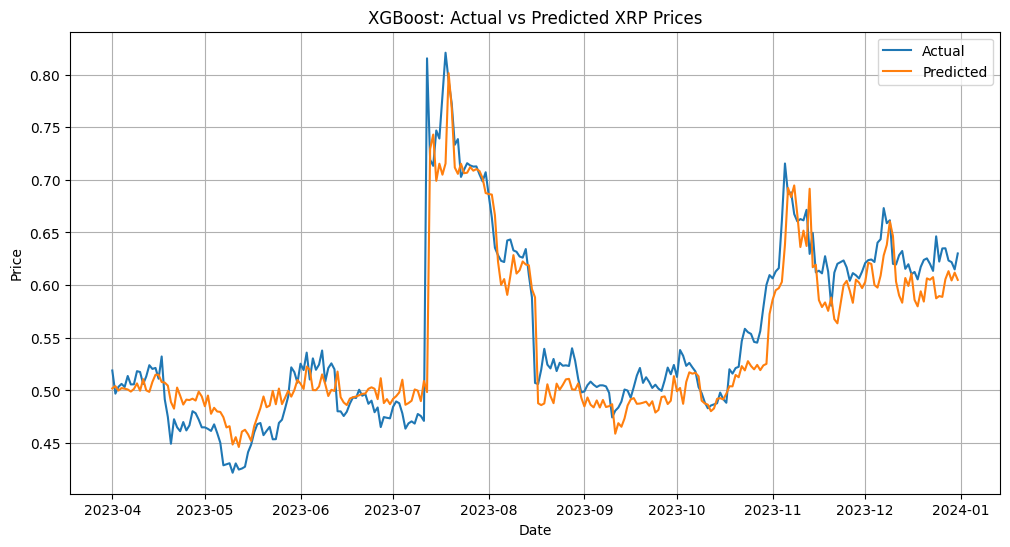

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(xrp_y_test_xgb.index,xrp_y_test_xgb.values, label="Actual")
plt.plot(xrp_y_test_xgb.index,xrp_preds_xgb, label="Predicted")
plt.title("XGBoost: Actual vs Predicted XRP Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

              Feature  Importance
0                High    0.379071
1                 Low    0.282046
21       Volume_MA_21    0.149007
2                Open    0.118808
5         Close_Lag_1    0.030358
23      Volume_MA_180    0.008308
20        Volume_MA_7    0.005263
14             MA_180    0.003261
27  Target_Return_365    0.002365
8        Close_Lag_30    0.002184


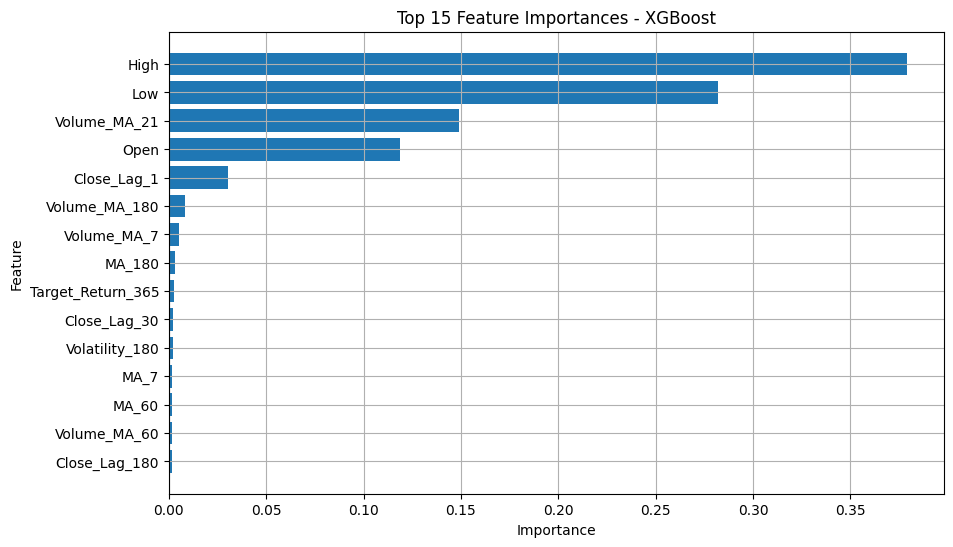

In [11]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": xrp_X_train_xgb.columns,
    "Importance": model_xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance.head(10))

plt.figure(figsize=(10, 6))
plt.barh(importance["Feature"].head(15)[::-1], importance["Importance"].head(15)[::-1])
plt.title("Top 15 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True)
plt.show()

## Finetuning Xgboost model

In [12]:
import optuna
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 500)
    max_depth = trial.suggest_int("max_depth", 3, 10)
    learning_rate = trial.suggest_float("learning_rate", 1e-3, 0.3, log=True)
    subsample = trial.suggest_float("subsample", 0.6, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0)

    model_xgb_opt = XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        objective="reg:squarederror",
        random_state=42
    )

    model_xgb_opt.fit(xrp_X_train_xgb, xrp_y_train_xgb)

    preds_xgb_opt = model_xgb_opt.predict(xrp_X_test_xgb)

    rmse_xgb_opt = np.sqrt(mean_squared_error(xrp_y_test_xgb, preds_xgb_opt))
    return rmse_xgb_opt

c:\Users\tharu\anaconda3\envs\Streamlit\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
study_xgb = optuna.create_study(
    direction="minimize",
    study_name="xgb_optuna_xrp",
    storage="sqlite:///xgb_optuna_xrp.db",
    load_if_exists=True
)

study_xgb.optimize(objective, n_trials=50)

[I 2026-04-14 16:25:16,836] Using an existing study with name 'xgb_optuna_xrp' instead of creating a new one.
[I 2026-04-14 16:25:18,151] Trial 50 finished with value: 0.03505504590201335 and parameters: {'n_estimators': 345, 'max_depth': 3, 'learning_rate': 0.004582325579532775, 'subsample': 0.8131157147321085, 'colsample_bytree': 0.8662981314850697}. Best is trial 24 with value: 0.029485797678236936.
[I 2026-04-14 16:25:19,189] Trial 51 finished with value: 0.03317197800928379 and parameters: {'n_estimators': 136, 'max_depth': 6, 'learning_rate': 0.11819488431185272, 'subsample': 0.6903836938499441, 'colsample_bytree': 0.7455576936278816}. Best is trial 24 with value: 0.029485797678236936.
[I 2026-04-14 16:25:21,270] Trial 52 finished with value: 0.030187813526730983 and parameters: {'n_estimators': 310, 'max_depth': 6, 'learning_rate': 0.013214447395230118, 'subsample': 0.7593468268755992, 'colsample_bytree': 0.801587789534792}. Best is trial 24 with value: 0.029485797678236936.
[I 

In [14]:
print("Best XGBoost RMSE:", study_xgb.best_value)
print("Best XGBoost Parameters:", study_xgb.best_params)

Best XGBoost RMSE: 0.028860243172326324
Best XGBoost Parameters: {'n_estimators': 257, 'max_depth': 4, 'learning_rate': 0.017152960580851095, 'subsample': 0.7484203119536567, 'colsample_bytree': 0.6883658914338}


In [15]:
best_params_xgb = study_xgb.best_params

model_xgb_best = XGBRegressor(
    n_estimators=best_params_xgb["n_estimators"],
    max_depth=best_params_xgb["max_depth"],
    learning_rate=best_params_xgb["learning_rate"],
    subsample=best_params_xgb["subsample"],
    colsample_bytree=best_params_xgb["colsample_bytree"],
    objective="reg:squarederror",
    random_state=42
)

model_xgb_best.fit(xrp_X_train_xgb, xrp_y_train_xgb)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6883658914338
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [16]:
xrp_preds_xgb_best = model_xgb_best.predict(xrp_X_test_xgb)

print("Predictions shape:", xrp_preds_xgb_best.shape)
print("First 10 predictions:", xrp_preds_xgb_best[:10])

Predictions shape: (275,)
First 10 predictions: [0.51137805 0.50523746 0.5124629  0.50766987 0.5047097  0.5049675
 0.5037623  0.5107647  0.51066774 0.50951964]


In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse_xgb_best = mean_squared_error(xrp_y_test_xgb, xrp_preds_xgb_best)
rmse_xgb_best = np.sqrt(mse_xgb_best)
mae_xgb_best = mean_absolute_error(xrp_y_test_xgb, xrp_preds_xgb_best)
r2_xgb_best = r2_score(xrp_y_test_xgb, xrp_preds_xgb_best)
mape_xgb_best = np.mean(np.abs((xrp_y_test_xgb - xrp_preds_xgb_best) / xrp_y_test_xgb)) * 100

print("Best XGBoost Results:")
print(f"MSE: {mse_xgb_best:.2f}")
print(f"RMSE: {rmse_xgb_best:.2f}")
print(f"MAE: {mae_xgb_best:.2f}")
print(f"R2 Score: {r2_xgb_best:.4f}")
print(f"MAPE: {mape_xgb_best:.2f}%")

Best XGBoost Results:
MSE: 0.00
RMSE: 0.03
MAE: 0.02
R2 Score: 0.8820
MAPE: 3.07%


# Saving the best performed final model for Ripple

In [19]:
import joblib

# Save model
joblib.dump(model_xgb_best, "Ripple_Final.pkl")

print("✅ XRP XGBoost model saved successfully!")

✅ XRP XGBoost model saved successfully!
